In [1]:
!pip install -q evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
import os
import rasterio
import kagglehub

# 1. Download (uses cache, efficient)
print("Downloading dataset...")
dataset_root = kagglehub.dataset_download("z789456sx/ts-satfire")
print(f"Dataset downloaded to: {dataset_root}")

# 2. Inspect the first TIF file found
print("\n--- Inspecting Data Structure ---")
tif_sample = None

# Walk through folders to find a .tif
for root, dirs, files in os.walk(dataset_root):
    for f in files:
        if f.endswith(".tif"):
            tif_sample = os.path.join(root, f)
            break
    if tif_sample: break

if tif_sample:
    with rasterio.open(tif_sample) as src:
        print(f"File: {os.path.basename(tif_sample)}")
        print(f"Shape: {src.width} x {src.height}")
        print(f"Total Bands: {src.count}")
        print("-" * 30)
        # Attempt to read descriptions (sometimes they are named 'Red', 'NIR', 'Mask')
        for i, name in enumerate(src.descriptions):
            desc = name if name else "No Description"
            print(f"Band {i+1}: {desc}")
else:
    print("No .tif files found! Check the download path.")

100%|██████████| 69.1G/69.1G [06:56<00:00, 178MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/z789456sx/ts-satfire/versions/12

--- Inspecting Data Structure ---
File: 2018-01-01_ESRI_LULC.tif
Shape: 22265 x 22313
Total Bands: 1
------------------------------
Band 1: lulc_classification


In [6]:
import os
import rasterio
import numpy as np
from tqdm import tqdm
import warnings

# --- CONFIGURATION ---
# Root where kagglehub downloaded the data
DATASET_ROOT = "/root/.cache/kagglehub/datasets/z789456sx/ts-satfire/versions/12/ts-satfire"
OUTPUT_DIR = "processed_dataset"
PATCH_SIZE = 512
STRIDE = 512  # No overlap

# Create output directories
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/masks", exist_ok=True)

print(f"Scanning events in: {DATASET_ROOT}")

# 1. Get all Event Folders (e.g., creek_fire, tubbs_fire)
event_folders = [d for d in os.listdir(DATASET_ROOT) if os.path.isdir(os.path.join(DATASET_ROOT, d))]
print(f"Found {len(event_folders)} events: {event_folders[:5]} ...")

total_patches = 0

for event in event_folders:
    event_path = os.path.join(DATASET_ROOT, event)

    # Define sub-paths
    img_dir = os.path.join(event_path, "VIIRS_Day")
    mask_dir = os.path.join(event_path, "FirePred")

    # Skip if folders don't exist
    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        continue

    # Get all dates available in the image folder
    # Filename format: YYYY-MM-DD_VIIRS_Day.tif
    img_files = [f for f in os.listdir(img_dir) if f.endswith(".tif")]

    for img_file in tqdm(img_files, desc=f"Processing {event}"):
        # Extract Date: "2020-09-07_VIIRS_Day.tif" -> "2020-09-07"
        date_part = img_file.split("_VIIRS")[0]

        # Construct matching Mask filename
        mask_file = f"{date_part}_FirePred.tif"

        img_full_path = os.path.join(img_dir, img_file)
        mask_full_path = os.path.join(mask_dir, mask_file)

        # Check if matching mask exists
        if not os.path.exists(mask_full_path):
            continue

        try:
            # Open Image and Mask
            with rasterio.open(img_full_path) as src_img, rasterio.open(mask_full_path) as src_mask:
                # Read Image (First 3 bands for RGB approximation)
                # Note: If < 3 bands, we stack.
                if src_img.count >= 3:
                    img_data = src_img.read([1, 2, 3])
                else:
                    single = src_img.read(1)
                    img_data = np.stack([single]*3)

                # Read Mask (Band 1)
                mask_data = src_mask.read(1)

                # Normalize Image to 0-255 (Byte)
                # We do this per-image to handle varying satellite brightness
                img_data = np.nan_to_num(img_data, nan=0.0) # Safety for NaNs
                img_min, img_max = img_data.min(), img_data.max()
                if img_max > img_min:
                    img_data = ((img_data - img_min) / (img_max - img_min) * 255).astype(np.uint8)
                else:
                    img_data = img_data.astype(np.uint8)

                # Move channels to last: (3, H, W) -> (H, W, 3)
                img_data = np.moveaxis(img_data, 0, -1)

                # --- TILING LOOP ---
                h, w, _ = img_data.shape

                for i in range(0, h - PATCH_SIZE + 1, STRIDE):
                    for j in range(0, w - PATCH_SIZE + 1, STRIDE):
                        # Crop
                        patch_img = img_data[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                        patch_mask = mask_data[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

                        # FILTER: Only save if the patch is not empty (contains some data)
                        # or specifically contains fire (optional, but good for class balance)
                        if np.mean(patch_img) > 1: # Simple check: is it not all black?

                            # Save Patch
                            patch_name = f"{event}_{date_part}_{i}_{j}.tif"

                            # Save Image
                            with rasterio.open(
                                f"{OUTPUT_DIR}/images/{patch_name}", 'w',
                                driver='GTiff', height=PATCH_SIZE, width=PATCH_SIZE,
                                count=3, dtype='uint8'
                            ) as dst:
                                dst.write(np.moveaxis(patch_img, -1, 0))

                            # Save Mask
                            with rasterio.open(
                                f"{OUTPUT_DIR}/masks/{patch_name}", 'w',
                                driver='GTiff', height=PATCH_SIZE, width=PATCH_SIZE,
                                count=1, dtype='int32'
                            ) as dst:
                                dst.write(patch_mask, 1)

                            total_patches += 1

        except Exception as e:
            # warnings.warn(f"Error processing {img_file}: {e}")
            pass

print(f"\n--- Tiling Complete ---")
print(f"Generated {total_patches} training patches in '{OUTPUT_DIR}'")

Scanning events in: /root/.cache/kagglehub/datasets/z789456sx/ts-satfire/versions/12/ts-satfire
Found 192 events: ['21889672', '21804582', '21751305', '24332732', '22141509'] ...


Processing 21804582:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
/usr/local/lib/python3.12/dist-packages/numpy/_core/_asarray.py:126: RuntimeWarning: invalid value encountered in cast
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)
Processing 24332760: 100%|██████████| 10/10 [00:03<00:00,  2.68it/s]


--- Tiling Complete ---
Generated 3547 training patches in 'processed_dataset'


In [8]:
import os
import rasterio
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
from transformers import TrainingArguments, Trainer
import evaluate

# --- 1. DATASET LOADER ---
class TiledFireDataset(Dataset):
    def __init__(self, root_dir, split="train", feature_extractor=None):
        self.img_dir = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "masks")
        self.feature_extractor = feature_extractor

        # List all files
        all_files = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.tif')])

        # Split 85% Train, 15% Validation
        split_idx = int(0.85 * len(all_files))
        if split == "train":
            self.files = all_files[:split_idx]
        else:
            self.files = all_files[split_idx:]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        # Load Image
        img_path = os.path.join(self.img_dir, filename)
        with rasterio.open(img_path) as src:
            image = src.read()
            image = np.moveaxis(image, 0, -1) # Convert to (H, W, C)

        # Load Mask
        mask_path = os.path.join(self.mask_dir, filename)
        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            # Ensure strict 0/1 labels
            mask = np.where(mask > 0, 1, 0).astype(np.int64)

        # Preprocess for Model
        encoded = self.feature_extractor(image, mask, return_tensors="pt")

        # Remove batch dimension
        for k in encoded.keys():
            encoded[k] = encoded[k].squeeze()

        return encoded

# --- 2. CONFIGURATION ---
# Initialize Feature Extractor
feature_extractor = SegformerFeatureExtractor.from_pretrained("nvidia/mit-b0")
feature_extractor.do_resize = False
feature_extractor.do_normalize = True

# Create Datasets
train_ds = TiledFireDataset("processed_dataset", split="train", feature_extractor=feature_extractor)
val_ds = TiledFireDataset("processed_dataset", split="val", feature_extractor=feature_extractor)

print(f"✅ Training samples: {len(train_ds)}")
print(f"✅ Validation samples: {len(val_ds)}")

# Load Model
id2label = {0: "background", 1: "fire"}
label2id = {"background": 0, "fire": 1}

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

# --- 3. METRICS ---
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    logits_tensor = torch.nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()

    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=2,
        ignore_index=255,
        reduce_labels=False,
    )

    return {
        "mean_iou": metrics["mean_iou"],
        "fire_iou": metrics["per_category_iou"][1],
        "accuracy": metrics["mean_accuracy"]
    }

# --- 4. TRAINING ARGUMENTS (FIXED) ---
training_args = TrainingArguments(
    output_dir="segformer_fire_model",
    learning_rate=6e-5,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="epoch",
    eval_strategy="epoch",       # <--- CHANGED HERE (was evaluation_strategy)
    save_total_limit=2,
    logging_steps=50,
    fp16=True,
    remove_unused_columns=False,
    report_to="none"
)

# --- 5. START TRAINING ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("\n🚀 Starting Training...")
trainer.train()

# Save final model
trainer.save_model("segformer_fire_model/final")
print("\n✅ Model saved to segformer_fire_model/final")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

✅ Training samples: 3014
✅ Validation samples: 533


/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:35: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  super().__init__(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

...


🚀 Starting Training...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Epoch,Training Loss,Validation Loss,Mean Iou,Fire Iou,Accuracy
1,0.080500,0.077854,0.781079,0.988062,0.811230
2,0.040700,0.045036,0.788482,0.988728,0.811771
3,0.035800,0.037731,0.796221,0.989223,0.817244
4,0.040400,0.037641,0.789721,0.988917,0.809637
5,0.029500,0.038541,0.787368,0.988700,0.809781


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs


✅ Model saved to segformer_fire_model/final


🧐 Inspecting Test Sample #223...


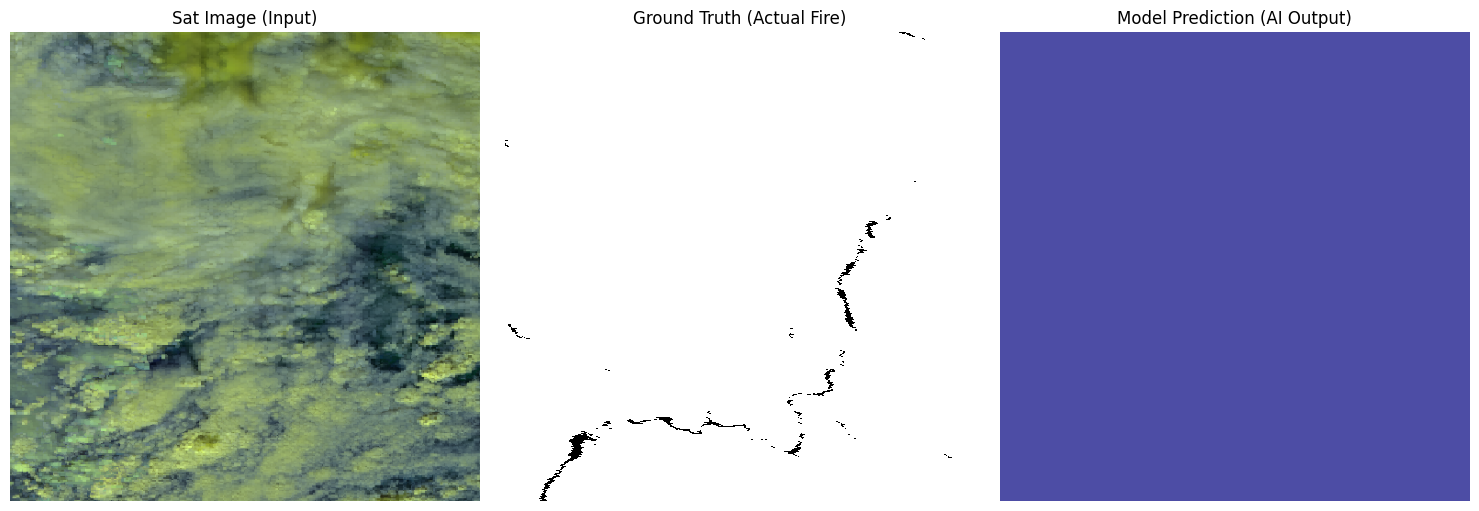

🧐 Inspecting Test Sample #238...


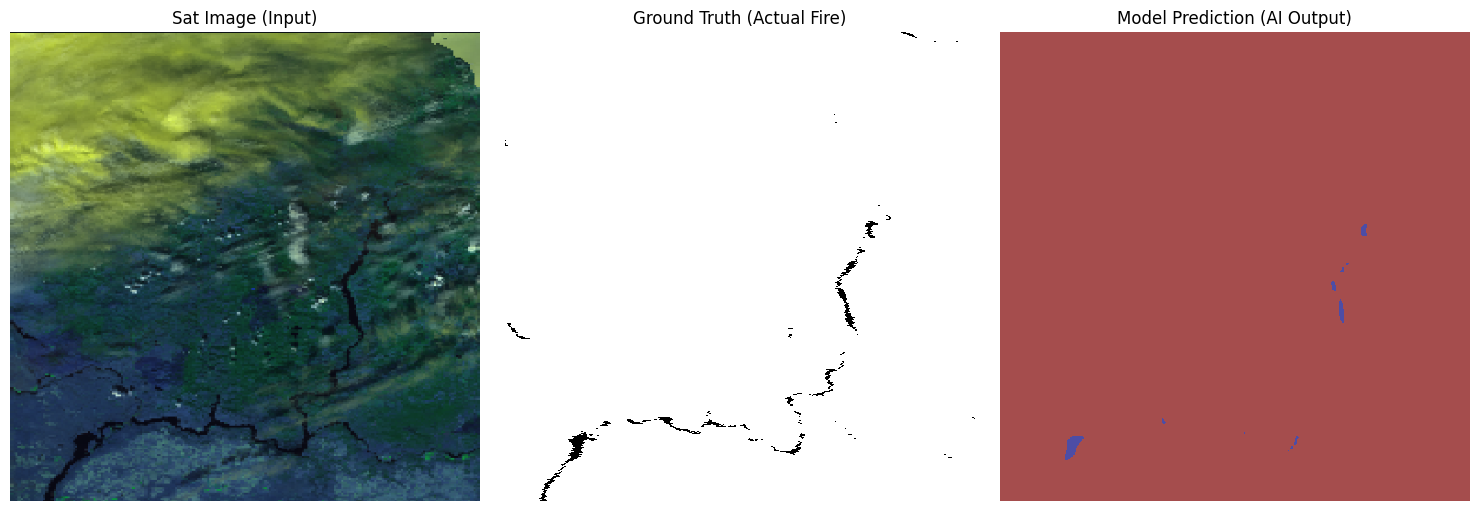

🧐 Inspecting Test Sample #517...


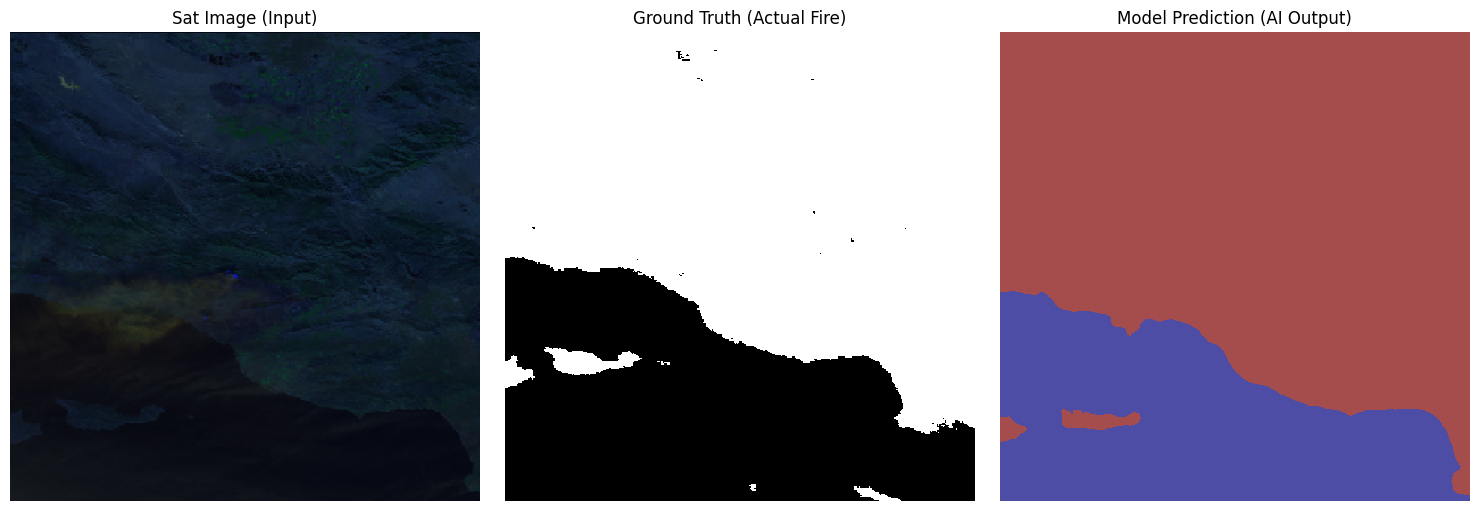

In [13]:
# --- Visual Test & Inspection Cell ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# 1. Define Test Set (Using Validation set for Baseline Phase)
test_ds = val_ds

def visualize_prediction(dataset, model, index=None):
    """
    Visualizes: Input Image | Ground Truth Mask | Predicted Mask
    """
    # Pick a random image if no index provided
    if index is None:
        index = random.randint(0, len(dataset)-1)

    print(f"🧐 Inspecting Test Sample #{index}...")

    # Load Data
    sample = dataset[index]
    image = sample['pixel_values']
    label = sample['labels']

    # Run Inference
    model.eval()
    model.to("cuda")
    with torch.no_grad():
        # Add batch dimension (C, H, W) -> (1, C, H, W)
        input_tensor = image.unsqueeze(0).to("cuda")
        outputs = model(pixel_values=input_tensor)

        # Upsample logits to original size (SegFormer output is 1/4th size)
        logits = torch.nn.functional.interpolate(
            outputs.logits,
            size=label.shape[-2:], # Match Ground Truth H,W
            mode="bilinear",
            align_corners=False
        )

        # Get Prediction (Argmax)
        pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Prepare for Plotting
    # Image: (C, H, W) -> (H, W, C) & Denormalize for display
    img_display = image.permute(1, 2, 0).numpy()

    # Normalize image to 0-1 range for matplotlib if it isn't already
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    axes[0].imshow(img_display)
    axes[0].set_title("Sat Image (Input)")
    axes[0].axis("off")

    # 2. Ground Truth
    axes[1].imshow(label, cmap="gray", interpolation="nearest")
    axes[1].set_title("Ground Truth (Actual Fire)")
    axes[1].axis("off")

    # 3. Prediction
    axes[2].imshow(pred_mask, cmap="jet", alpha=0.7, interpolation="nearest")
    axes[2].set_title("Model Prediction (AI Output)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# --- Run Visualization ---
# Run this multiple times to see different "Test" examples
for i in range(3):
    visualize_prediction(test_ds, model)

In [15]:
# --- Save Model to Google Drive ---
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
#
local_model_path = "./segformer_fire_model/final/"

# Define where you want it on Drive
# It will create a folder "Satellite_Project_Models" if it doesn't exist
drive_dest_path = f"/content/drive/MyDrive/Satellite_Project_Models/segformer-b0-ts-satfire"

# 3. Copy the Model
if os.path.exists(local_model_path):
    print(f"\n🚀 Copying model from {local_model_path} to {drive_dest_path}...")

    # If a version already exists on Drive, remove it to ensure we save the latest
    if os.path.exists(drive_dest_path):
        print("   (Overwriting existing version on Drive...)")
        shutil.rmtree(drive_dest_path)

    # Copy the directory
    shutil.copytree(local_model_path, drive_dest_path)
    print("✅ Success! Model safely saved to Google Drive.")
else:
    print(f"❌ Error: Could not find local model at {local_model_path}. Did the training finish?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🚀 Copying model from ./segformer_fire_model/final/ to /content/drive/MyDrive/Satellite_Project_Models/segformer-b0-ts-satfire...
✅ Success! Model safely saved to Google Drive.
